# Credit Card Fraud Detection

**Dataset:** the real Kaggle "Credit Card Fraud Detection" dataset —
284,807 European card transactions from September 2013, with 492
confirmed frauds (0.17%). Features `V1`-`V28` are anonymized via PCA;
`Time` and `Amount` are the only untouched columns.
Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

**Goal:** build a model that flags fraudulent transactions, evaluated
the way it would actually be judged in production — on realistic,
still-imbalanced data, using metrics that don't lie about a 99.8% normal
/ 0.2% fraud split.

**Pipeline:**
`Load data` → `EDA` → `Scale features` → `Train/test split (on real,
imbalanced data)` → `SMOTE the training fold only` → `Train 3 models` →
`Evaluate on the untouched imbalanced test set` → `Feature importance`


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, average_precision_score,
    f1_score, matthews_corrcoef
)

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_style("whitegrid")


## 1. Load the data


In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
df.head()


Shape: (284807, 31)
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

## 2. Exploratory Data Analysis

### 2.1 Class imbalance — the fact that drives every later decision


Fraud transactions: 0.173% of all 284,807 transactions (492 fraud cases)


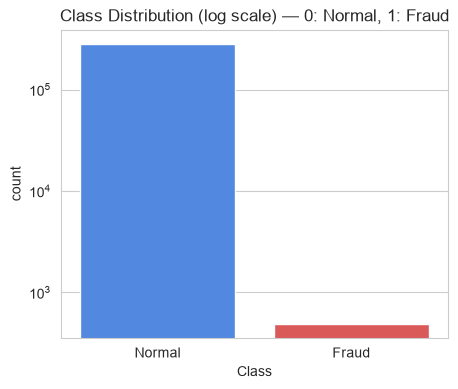

In [4]:
fraud_pct = df['Class'].mean() * 100
print(f"Fraud transactions: {fraud_pct:.3f}% of all {len(df):,} transactions "
      f"({df['Class'].sum()} fraud cases)")

plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df, palette=['#3b82f6', '#ef4444'])
plt.yscale('log')
plt.title('Class Distribution (log scale) — 0: Normal, 1: Fraud')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.show()


### 2.2 Transaction amount — does fraud look different?


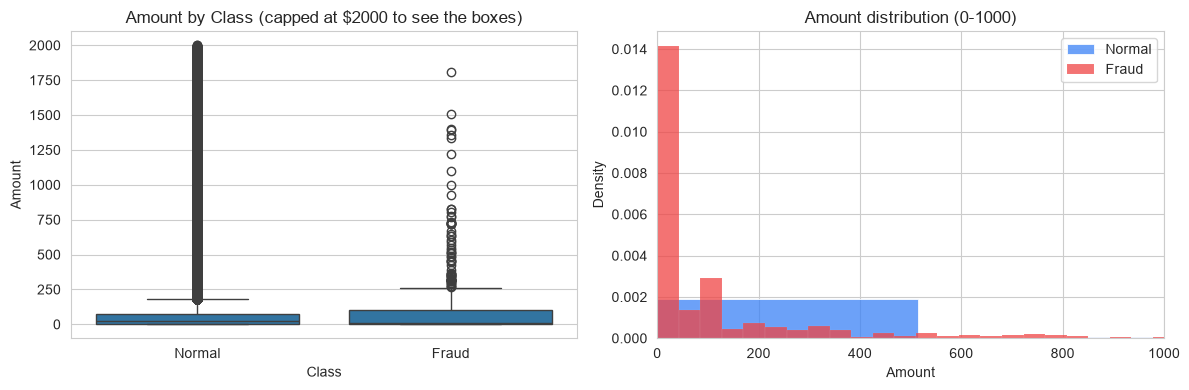

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x='Class', y='Amount', data=df[df['Amount'] < 2000], ax=axes[0])
axes[0].set_xticklabels(['Normal', 'Fraud'])
axes[0].set_title('Amount by Class (capped at $2000 to see the boxes)')

sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='#3b82f6', label='Normal', stat='density', ax=axes[1])
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='#ef4444', label='Fraud', stat='density', ax=axes[1])
axes[1].set_xlim(0, 1000)
axes[1].legend()
axes[1].set_title('Amount distribution (0-1000)')
plt.tight_layout()
plt.show()

print(df.groupby('Class')['Amount'].describe())


**Observation:** fraudulent transactions tend to cluster at lower
amounts than the full normal-transaction range, and have far fewer
high-value outliers — makes sense, since large unusual charges are more
likely to trigger a cardholder's own fraud alerts before the transaction
even completes.


### 2.3 Time of day — is fraud more common at certain hours?

`Time` is seconds elapsed since the first transaction, across ~2 days.
Converting to hour-of-day makes the pattern human-readable.


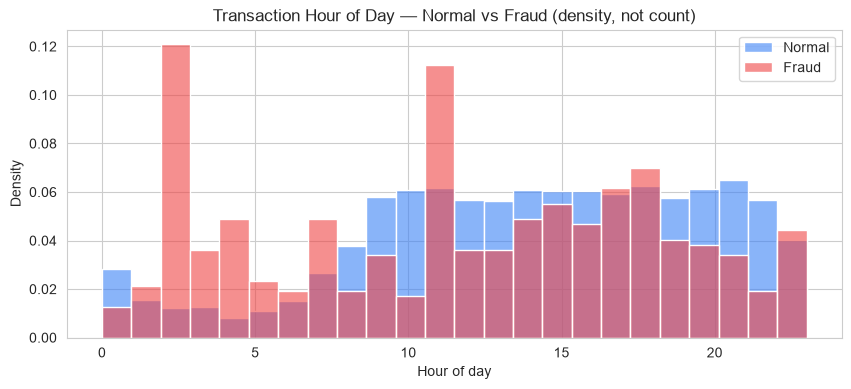

In [6]:
df['Hour'] = (df['Time'] // 3600) % 24

fig, ax = plt.subplots(figsize=(10,4))
sns.histplot(df[df['Class']==0]['Hour'], bins=24, color='#3b82f6', label='Normal', stat='density', alpha=0.6, ax=ax)
sns.histplot(df[df['Class']==1]['Hour'], bins=24, color='#ef4444', label='Fraud', stat='density', alpha=0.6, ax=ax)
ax.set_title('Transaction Hour of Day — Normal vs Fraud (density, not count)')
ax.set_xlabel('Hour of day')
ax.legend()
plt.show()


**Observation:** normal transactions dip heavily during typical
overnight hours, while fraud is spread more evenly across the day —
consistent with fraud not following normal human shopping rhythms.
`Hour` is a useful engineered feature but we won't feed it into the model
directly, since `Time` is already available in scaled form; it's here
purely for the visual insight.


### 2.4 Which features correlate most with fraud?


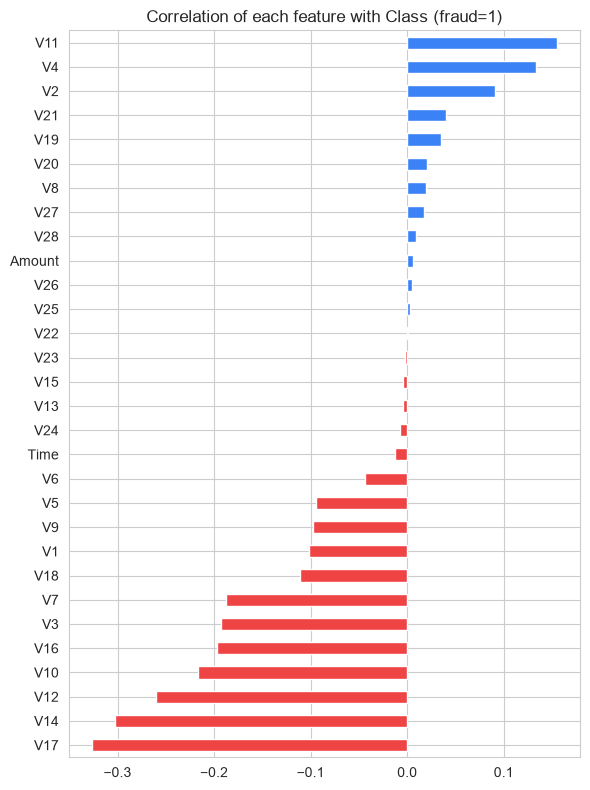

Strongest negative correlations:
 V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Strongest positive correlations:
 V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


In [7]:
corr_with_class = df.drop(columns=['Hour']).corr(numeric_only=True)['Class'].drop('Class').sort_values()

plt.figure(figsize=(6,8))
corr_with_class.plot(kind='barh', color=['#ef4444' if v < 0 else '#3b82f6' for v in corr_with_class])
plt.title('Correlation of each feature with Class (fraud=1)')
plt.tight_layout()
plt.show()

print("Strongest negative correlations:\n", corr_with_class.head(5))
print("\nStrongest positive correlations:\n", corr_with_class.tail(5))


### 2.5 A 2D visual — can fraud even be separated?

A quick PCA projection down to 2 dimensions, just to eyeball whether
fraud and normal transactions form visually distinguishable clusters
before we train anything.


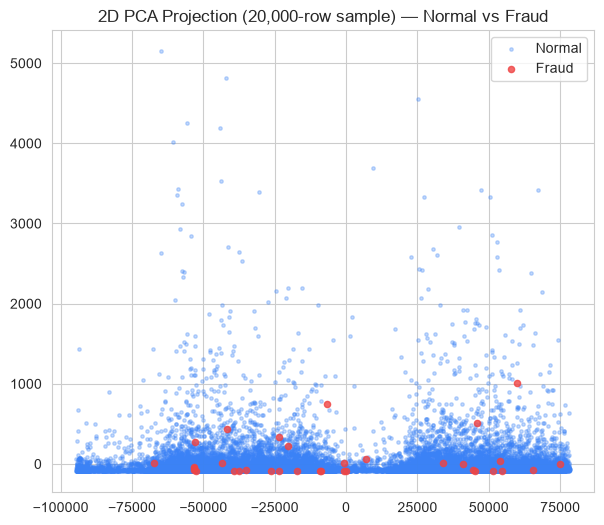

In [8]:
sample = df.sample(n=20000, random_state=42)  # subsample purely for a fast, readable scatter plot
pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(sample.drop(columns=['Class','Hour']))

plt.figure(figsize=(7,6))
plt.scatter(coords[sample['Class']==0,0], coords[sample['Class']==0,1],
            s=6, alpha=0.3, color='#3b82f6', label='Normal')
plt.scatter(coords[sample['Class']==1,0], coords[sample['Class']==1,1],
            s=20, alpha=0.8, color='#ef4444', label='Fraud')
plt.title('2D PCA Projection (20,000-row sample) — Normal vs Fraud')
plt.legend()
plt.show()


**Observation:** fraud points (red) visibly cluster away from the
bulk of normal transactions rather than being scattered randomly through
them — a good sign that a model has real signal to learn from, not just
noise.


## 3. Preprocessing

`V1`-`V28` are already PCA-scaled. `Amount` and `Time` are on very
different raw scales, so we scale them with `RobustScaler` (uses
median/IQR, so the handful of very large transactions don't distort it).


In [9]:
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])
df = df.drop(columns=['Amount', 'Time', 'Hour'])

X = df.drop(columns=['Class'])
y = df['Class']
X.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,-0.994960


## 4. Train/test split — on the REAL, imbalanced data

> **The mistake to avoid:** don't balance (undersample/SMOTE) the *whole*
> dataset and split it afterward — that leaks balanced information into
> your test set and inflates every metric you report. Split first, on
> the original imbalanced data. Only ever touch the training fold after
> that.

`stratify=y` keeps the same ~0.17% fraud ratio in both sets.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, " fraud ratio:", round(y_train.mean(), 5))
print("Test: ", X_test.shape,  " fraud ratio:", round(y_test.mean(), 5))


Train: (227845, 30)  fraud ratio: 0.00173
Test:  (56962, 30)  fraud ratio: 0.00172


## 5. SMOTE — rebalance the TRAINING fold only

SMOTE (Synthetic Minority Over-sampling Technique) creates new,
synthetic fraud examples by interpolating between real fraud examples in
feature space, giving the model more varied minority-class examples to
learn from — rather than just reweighting or duplicating existing ones.

We use `sampling_strategy=0.1` (fraud becomes 10% of the training data,
not a full 50/50) — a fully 1:1 balanced training set is unusual in
practice and risks overfitting on synthetic points; a partial rebalance
is a more realistic, commonly-used middle ground, and trains much faster
on a dataset this size.

**`X_test` / `y_test` are never touched by this step.**


In [11]:
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_res.value_counts().to_dict())


Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 22745}


## 6. Train three models

One model from each major family — enough range to demonstrate breadth,
few enough to explain each one in depth:

| Model | Family | Why |
|---|---|---|
| Logistic Regression | Linear | Fast, interpretable baseline |
| Random Forest | Bagging ensemble | Robust, resists overfitting, gives feature importance |
| XGBoost | Boosting ensemble | Sequentially corrects errors; usually the strongest on tabular data |


In [12]:
log_reg = LogisticRegression(C=0.1, max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train_res, y_train_res)
print("Logistic Regression trained.")


Logistic Regression trained.


In [13]:
rf = RandomForestClassifier(n_estimators=100, max_depth=14, min_samples_split=10,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
print("Random Forest trained.")


Random Forest trained.


In [14]:
xgb_clf = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1,
                         eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_clf.fit(X_train_res, y_train_res)
print("XGBoost trained.")


XGBoost trained.


## 7. Evaluate — on the untouched, imbalanced test set

This is the number that matters: performance on data shaped like what
the model would actually see in production. Accuracy is not reported as
a headline metric — it's meaningless on a 99.8%/0.2% split.


In [15]:
models = {"Logistic Regression": log_reg, "Random Forest": rf, "XGBoost": xgb_clf}
rows = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Precision": round(classification_report(y_test, y_pred, output_dict=True)['1']['precision'], 4),
        "Recall":    round(classification_report(y_test, y_pred, output_dict=True)['1']['recall'], 4),
        "F1":        round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_proba), 4),
        "PR-AUC":    round(average_precision_score(y_test, y_proba), 4),
        "MCC":       round(matthews_corrcoef(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(rows).set_index("Model")
results_df


,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
Model,,,,,,
Logistic Regression,0.3522,0.8878,0.5043,0.9676,0.7510,0.5581
Random Forest,0.8317,0.8571,0.8442,0.9824,0.8781,0.8440
XGBoost,0.7810,0.8367,0.8079,0.9772,0.8713,0.8080


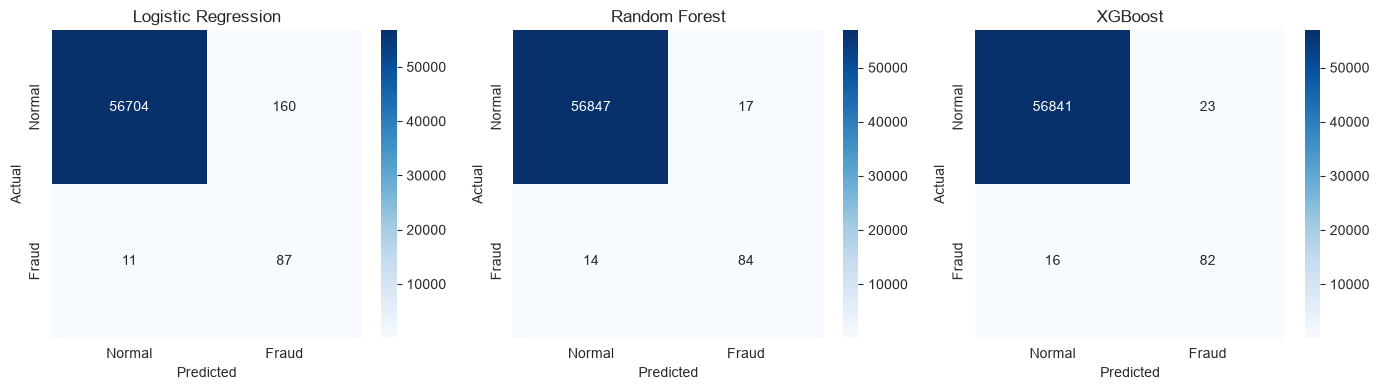

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


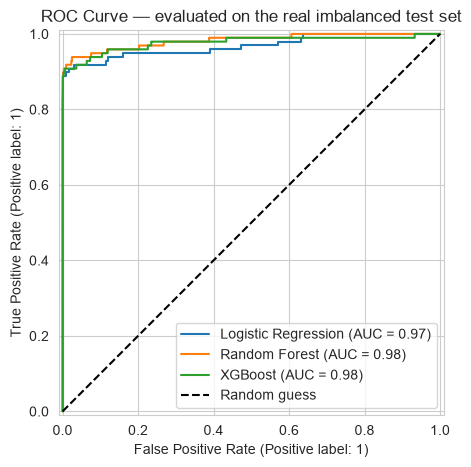

In [17]:
fig, ax = plt.subplots(figsize=(6,5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0,1],[0,1],'k--', label='Random guess')
ax.set_title('ROC Curve — evaluated on the real imbalanced test set')
ax.legend()
plt.show()


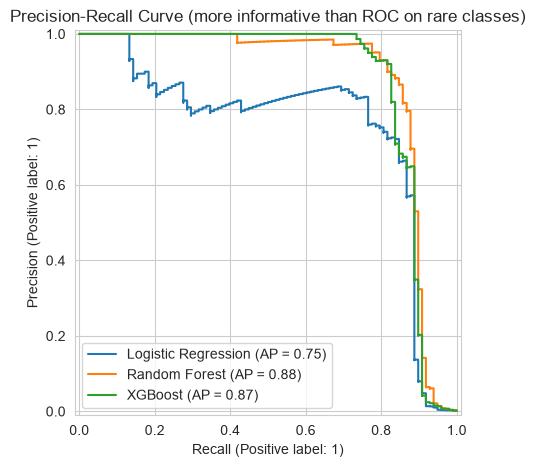

In [18]:
fig, ax = plt.subplots(figsize=(6,5))
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title('Precision-Recall Curve (more informative than ROC on rare classes)')
plt.show()


## 8. Feature importance (Random Forest)

Which columns the model actually relies on — a natural thing to point to
in an interview, and a sanity check against the correlation chart from
the EDA section.


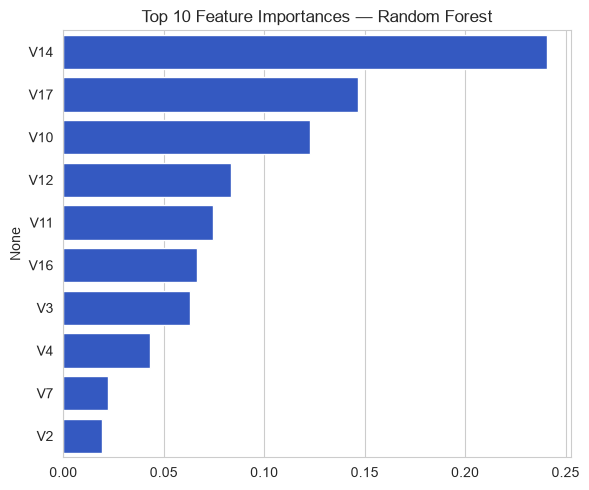

In [19]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(6,5))
sns.barplot(x=importances.values, y=importances.index, color='#1d4ed8')
plt.title('Top 10 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()


## 9. Conclusion

- Fraud is 0.17% of real transactions — accuracy is not a usable metric;
  precision, recall, F1, ROC-AUC, PR-AUC, and MCC are used instead.
- The training fold was partially rebalanced with SMOTE
  (`sampling_strategy=0.1`); the test fold was left untouched and
  imbalanced, so every metric above reflects realistic production
  performance rather than an inflated, easier benchmark.
- Three models from three different families (linear, bagging, boosting)
  are compared side-by-side on identical, real-world-shaped test data —
  see the trade-offs in the results table above.

**Natural next steps** : tune the
classification threshold instead of the default 0.5, since the
precision/recall trade-off matters more than accuracy here; try
cross-validation instead of a single split; add SHAP for
explainability; in a real deployment, monitor for concept drift, since
fraud patterns evolve over time and periodic retraining would be needed.
